# Proyek Klasifikasi Gambar: 5 Flower Types Classification
- **Nama:** Muhammad Bagas Wahyudi
- **Email:** mbagaswahyudi03@gmail.com
- **ID Dicoding:** muhammadbagaswhyudi

## Import Semua Packages/Library yang Digunakan

In [21]:
!pip install -q kagglehub

In [22]:
import kagglehub
import numpy as np
import os
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

## Data Preparation

### Data Loading

Saya pakai dataset 5 Flower Types Classification dari Kaggle (Lilly, Lotus, Sunflower, Orchid, Tulip, masing-masing 1000 gambar).

Link: https://www.kaggle.com/datasets/kausthubkannan/5-flower-types-classification-dataset/data

### Download Dataset

In [23]:
# Download latest version
path = kagglehub.dataset_download("kausthubkannan/5-flower-types-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '5-flower-types-classification-dataset' dataset.
Path to dataset files: /kaggle/input/5-flower-types-classification-dataset


### Cek struktur dataset

In [24]:
data_dir = f"{path}/flower_images"
print("Isi folder path:", os.listdir(path))

# ['flower_images']
data_dir = os.path.join(path, "flower_images")
print("Isi data_dir:", os.listdir(data_dir))

# Cek jumlah gambar per kelas
print("\nJumlah gambar per kelas:")
total_images = 0
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        # Filter hanya file gambar (opsional, jika ada file non-gambar)
        # images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        count = len(files)
        print(f"- {folder}: {count} gambar")
        total_images += count

print(f"\nTotal seluruh gambar: {total_images}")

Isi folder path: ['flower_images']
Isi data_dir: ['Orchid', 'Sunflower', 'Tulip', 'Lotus', 'Lilly']

Jumlah gambar per kelas:
- Orchid: 1000 gambar
- Sunflower: 1000 gambar
- Tulip: 1000 gambar
- Lotus: 1000 gambar
- Lilly: 1000 gambar

Total seluruh gambar: 5000


## Data Preprocessing

### Split Dataset

Kode ini akan membagi dataset menjadi data latih, data validasi, dan data uji.



In [25]:
# Parameter
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Memuat dataset menggunakan image_dataset_from_directory
# Kita bagi: 80% Train, 20% Sisanya (untuk Val dan Test)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Membagi val_test_ds menjadi Validation dan Test (masing-masing 50% dari 20%)
val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

print(f"Jumlah batch Train: {tf.data.experimental.cardinality(train_ds)}")
print(f"Jumlah batch Val  : {tf.data.experimental.cardinality(val_ds)}")
print(f"Jumlah batch Test : {tf.data.experimental.cardinality(test_ds)}")

# Konfigurasi performa dataset (Cache & Prefetch)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 4999 files belonging to 5 classes.
Using 4000 files for training.
Found 4999 files belonging to 5 classes.
Using 999 files for validation.
Jumlah batch Train: 125
Jumlah batch Val  : 16
Jumlah batch Test : 16


### Normalisasi dan Augmentasi Data

In [26]:
# Definisikan layer Augmentasi dan Normalisasi
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

# Normalisasi pixel value dari 0-255 menjadi 0-1
normalization_layer = layers.Rescaling(1./255)

# Terapkan augmentasi HANYA pada data training
# Terapkan normalisasi pada semua data
train_ds = train_ds.map(lambda x, y: (normalization_layer(data_augmentation(x, training=True)), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

## Modelling

In [27]:
# Base Model (Transfer Learning)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Bekukan dulu

In [28]:
# Bangun Model Sequential dengan Layer Eksplisit
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Base Model
    base_model,
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(5, activation='softmax')
])

In [29]:
# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,031,173 (11.56 MB)

 Trainable params: 773,189 (2.95 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Training
print("Memulai Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,  # Dengan transfer learning, butuh waktu singkat
    callbacks=[early_stopping, reduce_lr]
)

Memulai Training...
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.6072 - loss: 1.0003 - val_accuracy: 0.8378 - val_loss: 0.5678 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.7347 - loss: 0.7164 - val_accuracy: 0.8398 - val_loss: 0.4709 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.7780 - loss: 0.6274 - val_accuracy: 0.8706 - val_loss: 0.4043 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.7962 - loss: 0.5638 - val_accuracy: 0.8522 - val_loss: 0.4161 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.8040 - loss: 0.5349 - val_accuracy: 0.8522 - val_loss: 0.3851 - learning_rate: 0.0010
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.8183 - loss: 0.5095 - val_accuracy: 0.8686 - val_loss: 0.4041 - learning_rate: 0.0010
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accurac

## Evaluasi dan Visualisasi

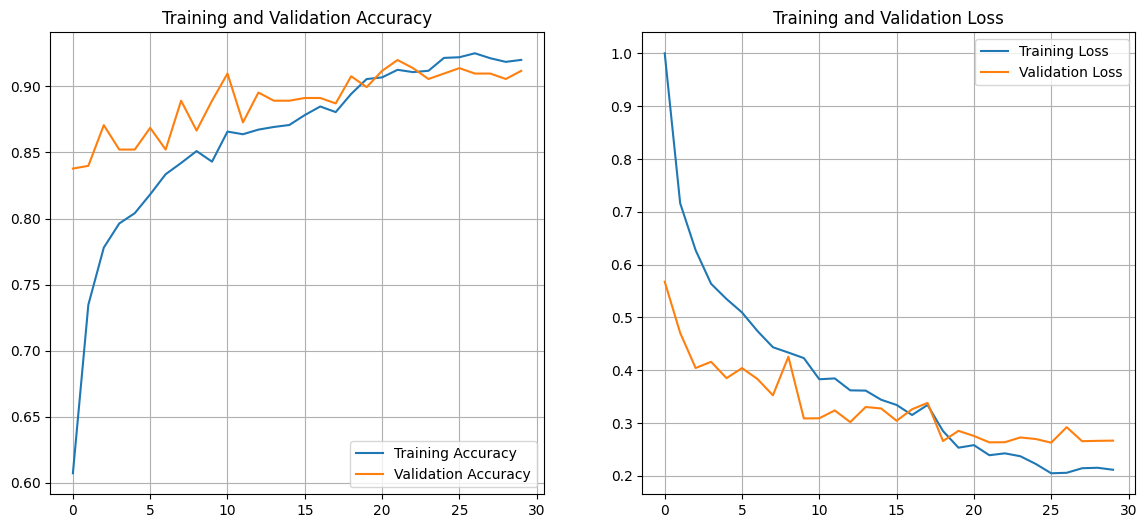


HASIL EVALUASI AKHIR
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9004 - loss: 0.3007


Training Accuracy: 0.9200
Test Accuracy    : 0.9004

✅ Status: LULUS
Kedua akurasi (Training & Testing) memenuhi syarat minimal 85%.
Model berhasil disimpan ke 'model_flower_final.h5'


In [32]:
# Visualisasi
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)

plt.show()

# Evaluasi Numerik
print("\n" + "="*50)
print("HASIL EVALUASI AKHIR")
print("="*50)

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
train_acc = history.history['accuracy'][-1]

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy    : {test_acc:.4f}")

if (train_acc >= 0.85) and (test_acc >= 0.85):
    print("\n✅ Status: LULUS")
    print("Kedua akurasi (Training & Testing) memenuhi syarat minimal 85%.")
else:
    print("\n❌ Status: TIDAK LULUS")
print("="*50)

# Simpan model ke file .h5 agar tidak hilang lagi
model.save('model_flower_final.h5')
print("Model berhasil disimpan ke 'model_flower_final.h5'")

## Konversi Model

In [33]:
# Konversi ke SavedModel
saved_model_path = './saved_model'
os.makedirs(saved_model_path, exist_ok=True)

# Simpan model ke format SavedModel
tf.saved_model.save(model, saved_model_path)
print(f"✅ SavedModel berhasil disimpan di: {saved_model_path}")

# Verifikasi isi
print("Isi folder SavedModel:", os.listdir(saved_model_path))

✅ SavedModel berhasil disimpan di: ./saved_model
Isi folder SavedModel: ['saved_model.pb', 'fingerprint.pb', 'variables', 'assets']


In [34]:
# Konversi ke TensorFlow Lite

tflite_dir = './tflite'
os.makedirs(tflite_dir, exist_ok=True)

# Inisialisasi converter dari model Keras
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan file .tflite
tflite_model_file = os.path.join(tflite_dir, 'model.tflite')
with open(tflite_model_file, 'wb') as f:
    f.write(tflite_model)

# Buat label.txt (Urutan label harus sesuai os.listdir data_dir)
class_names = sorted(os.listdir(data_dir))
with open(os.path.join(tflite_dir, 'label.txt'), 'w') as f:
    for name in class_names:
        f.write(name + '\n')

print(f"✅ TensorFlow Lite berhasil disimpan di: {tflite_dir}")
print("Isi folder TFLite:", os.listdir(tflite_dir))

Saved artifact at '/tmp/tmpgdl3g0_l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_332')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133452432731280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133452432720912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454997055504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133452432727824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133452432719952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133452432730896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133452432728016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133452579158544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133452432720720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133452432720528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1334525791

In [35]:
# Konversi ke TensorFlow.js

# Install library tensorflowjs
!pip install -q tensorflowjs

# Gunakan CLI converter (paling stabil untuk menghindari import error di Colab)
# Perintah ini mengubah SavedModel menjadi TFJS format
!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model ./saved_model ./tfjs_model

print(f"✅ TensorFlow.js berhasil disimpan di: ./tfjs_model")
# Verifikasi isi
if os.path.exists('./tfjs_model/model.json'):
    print("Isi folder TFJS:", os.listdir('./tfjs_model'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 905.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigquery-magics 0.14.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.41.0 requires packaging>=24.2.0, but you have packaging 2

## Inference (Optional)

✅ Model berhasil dimuat dari 'model_flower_final.h5'.

--- Contoh Inference dari Test Set ---
Prediksi: Lotus (40.46%)


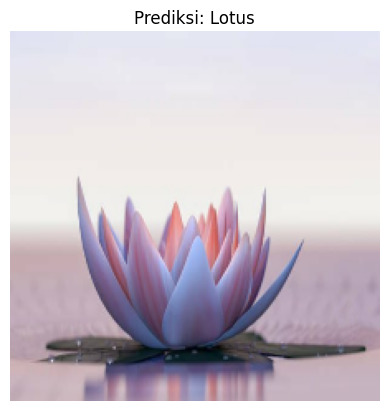

Label Asli: Lotus


In [36]:
from tensorflow.keras.utils import load_img, img_to_array

# Load Model yang Sudah Disimpan
# Pastikan file 'model_flower_final.h5' ada dari proses training sebelumnya
try:
    loaded_model = tf.keras.models.load_model('model_flower_final.h5')
    print("✅ Model berhasil dimuat dari 'model_flower_final.h5'.")
except:
    print("❌ File model tidak ditemukan. Menggunakan model dari memori saat ini.")
    loaded_model = model

# Definisikan Label Kelas (Urutan harus sesuai dengan training: sorted alphabetically)
class_names = ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']

# Fungsi untuk Melakukan Prediksi
def predict_flower(image_path=None, image_array=None):
    """
    Fungsi untuk memprediksi jenis bunga.
    Bisa input path gambar (untuk upload) atau array gambar (dari dataset).
    """
    if image_path:
        # Load dan preprocess untuk gambar baru (upload)
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = img_array / 255.0 # Normalisasi
        img_array = np.expand_dims(img_array, axis=0) # Tambah dimensi batch

        # Tampilkan gambar
        plt.imshow(img)
        plt.axis("off")

    elif image_array is not None:
        # Gunakan array yang sudah ada (dari dataset test_ds)
        # Pastikan sudah dinormalisasi (jika belum, lakukan normalisasi)
        if image_array.max() > 1.0:
            image_array = image_array / 255.0

        # Tampilkan gambar
        plt.imshow(image_array)
        plt.axis("off")

        # Tambah dimensi batch
        img_array = np.expand_dims(image_array, axis=0)

    else:
        print("Tidak ada input gambar.")
        return

    # Lakukan prediksi
    predictions = loaded_model.predict(img_array, verbose=0)
    score = tf.nn.softmax(predictions[0])

    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    print(f"Prediksi: {predicted_class} ({confidence:.2f}%)")
    plt.title(f"Prediksi: {predicted_class}")
    plt.show()

# Inference menggunakan Test Set
print("\n--- Contoh Inference dari Test Set ---")

# Ambil satu batch dari test_ds
image_batch, label_batch = next(iter(test_ds))

# Ambil gambar pertama dari batch
img_test = image_batch[0].numpy()
true_label_idx = np.argmax(label_batch[0])

# Lakukan Prediksi
predict_flower(image_array=img_test)
print(f"Label Asli: {class_names[true_label_idx]}")

In [38]:
!pip freeze > requirements.txt